In [1]:
from hyperopt import hp

In [2]:
#-10에서 10까지 1간격을 가지는 입력변수 x와  -15에서 15까지 1간격으로 입력변수 y 설정 
search_space = {'x':hp.quniform('x', -10, 10, 1), 'y':hp.quniform('y',-15, 15, 1)}

In [3]:
from hyperopt import STATUS_OK 
#목적 함수를 생성. 변수값과 변수 검색 공간을 가지는 딕셔너리를 인자로 받고, 특정값을 반환 
def objective_func(search_space):
    x= search_space['x']
    y= search_space['y']
    retval = x**2 - 20 * y
    return retval 

In [6]:
from hyperopt import fmin, tpe, Trials
import numpy as np
#입력 결괏값을 저장한 Trials 객체값 생성 
trial_val = Trials()

#목적 함수의 최솟값을 반환하는 최적 입력변수 값을 5번의 입력값 시도(max_evals = 5) 로 찾아냄 
best_01 = fmin(fn = objective_func, space = search_space, algo=tpe.suggest, max_evals = 5, 
               trials  = trial_val, rstate = np.random.default_rng(seed = 0))
print('best:', best_01)

100%|████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 1216.52trial/s, best loss: -224.0]
best: {'x': -4.0, 'y': 12.0}


In [8]:
trial_val = Trials()
#max_evals를 20회로 늘려서 재테스트 
best_02 = fmin(fn = objective_func, space = search_space, algo = tpe.suggest, max_evals = 20, 
               trials = trial_val, rstate = np.random.default_rng(seed = 0))
print('best:', best_02)

100%|██████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 1428.41trial/s, best loss: -296.0]
best: {'x': 2.0, 'y': 15.0}


In [10]:
#fmin() 에 인자로 들어가는 Trials 객체의 result 속성에 파이썬 리스트로 목적함수 반환값들이 저장됨 
#리스트 내부의 개별 원소는 {loss:함수의 반환값, status: 반환 상태값} 와 같은 딕셔너리임 

print(trial_val.results)

[{'loss': -64.0, 'status': 'ok'}, {'loss': -184.0, 'status': 'ok'}, {'loss': 56.0, 'status': 'ok'}, {'loss': -224.0, 'status': 'ok'}, {'loss': 61.0, 'status': 'ok'}, {'loss': -296.0, 'status': 'ok'}, {'loss': -40.0, 'status': 'ok'}, {'loss': 281.0, 'status': 'ok'}, {'loss': 64.0, 'status': 'ok'}, {'loss': 100.0, 'status': 'ok'}, {'loss': 60.0, 'status': 'ok'}, {'loss': -39.0, 'status': 'ok'}, {'loss': 1.0, 'status': 'ok'}, {'loss': -164.0, 'status': 'ok'}, {'loss': 21.0, 'status': 'ok'}, {'loss': -56.0, 'status': 'ok'}, {'loss': 284.0, 'status': 'ok'}, {'loss': 176.0, 'status': 'ok'}, {'loss': -171.0, 'status': 'ok'}, {'loss': 0.0, 'status': 'ok'}]


In [11]:
#Trial 객체의 vals 속성에 {'입력변수명': 개별 수행시마다 입력된 값 리스트} 형태로 저장됨 
print(trial_val.vals)

{'x': [-6.0, -4.0, 4.0, -4.0, 9.0, 2.0, 10.0, -9.0, -8.0, -0.0, -0.0, 1.0, 9.0, 6.0, 9.0, 2.0, -2.0, -4.0, 7.0, -0.0], 'y': [5.0, 10.0, -2.0, 12.0, 1.0, 15.0, 7.0, -10.0, 0.0, -5.0, -3.0, 2.0, 4.0, 10.0, 3.0, 3.0, -14.0, -8.0, 11.0, -0.0]}


In [12]:
import pandas as pd 
#result 에서 loss 키값에 해당하는 벨류들을 추출 하여 list 로 생성 
losses = [loss_dict['loss'] for loss_dict in trial_val.results]

#DataFrame 생성 
result_df = pd.DataFrame({'x':trial_val.vals['x'],'y':trial_val.vals['y'], 'losses':losses})
result_df

,x,y,losses
0,-6.0,5.0,-64.0
1,-4.0,10.0,-184.0
2,4.0,-2.0,56.0
3,-4.0,12.0,-224.0
4,9.0,1.0,61.0
5,2.0,15.0,-296.0
6,10.0,7.0,-40.0
7,-9.0,-10.0,281.0
8,-8.0,0.0,64.0
9,-0.0,-5.0,100.0


In [13]:
import pandas as pd 
import numpy as np 
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from lightgbm import early_stopping, log_evaluation

dataset = load_breast_cancer()
cancer_df = pd.DataFrame(data = dataset.data, columns = dataset.feature_names)
cancer_df['target'] = dataset.target
X_features = cancer_df.iloc[:,:-1]
y_label = cancer_df.iloc[:,-1]
#전제 데이터 중 80프로는 학습용 나머지 20프로는 테스트 데이터 추출 
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size = 0.2, random_state = 156)
#위에서 만든 X_train, y_train을 다시 쪼개서 90프로는 학습과 10프로는 검증용 데이터로 분리 
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = 0.1, random_state = 156)


In [14]:
from hyperopt import hp
#max_depth는 5에서 20까지 1간격으로, min_child_weight는 1에서 2까지 1간경르ㅗ 
#colsample_bytree는 0.5 에서 1사이, learning_rate는 0.01에서 0.2  사이 정규 분포된 값으로 검색 

xgb_search_space = {'max_depth':hp.quniform('max_depth', 5, 20, 1),
                    'min_child_weight':hp.quniform('min_child_weight', 1, 2, 1),
                    'learning_rate':hp.uniform('learning_rate', 0.01, 0.2),
                    'colsample_bytree':hp.uniform('colsample_bytree', 0.5, 1),
                   }


In [15]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from hyperopt import STATUS_OK

#fmin() 에서 입력된 search_space 값으로 입력된 모든 값은 실수형임
#XGBClassifier의 정수형 하이퍼 파라미터는 정수형 반환을 해줘야함 
#정확도는 높을수록 더 좋은 수치임 -1 * 정확도을 곱해서 큰 정확도 값일 수록 최소가 되도록 변환 
def objective_func(search_space):
    #수행 시간 절약을 위해 nestimators는 100으로 축소 
    xgb_clf = XGBClassifier(n_estimators = 100, max_depth = int(search_space['max_depth']), 
                            min_child_weight = int(search_space['min_child_weight']),
                            learning_rate = search_space['learning_rate'],
                            colsample_bytree = search_space['colsample_bytree'],
                            eval_metric = 'logloss')
    accuracy = cross_val_score(xgb_clf, X_train, y_train, scoring = 'accuracy', cv = 3)
    #accuracy는  cv = 3 개수 만큼 roc-auc 결과를 리스트로 가짐. 이를 평균해서 반환하되 -1을 곱함 
    return {'loss':-1*np.mean(accuracy), 'status':STATUS_OK}

In [17]:
from hyperopt import fmin, tpe, Trials
trial_vals = Trials()
best = fmin(fn = objective_func, 
            space = xgb_search_space, 
            algo = tpe.suggest, 
            max_evals = 50, #최대 반복 횟수를 지정 
            trials = trial_vals, rstate = np.random.default_rng(seed = 9))
print('best:',best)

100%|███████████████████████████████████████████████| 50/50 [00:36<00:00,  1.39trial/s, best loss: -0.9692401533635412]
best: {'colsample_bytree': 0.7816916965882073, 'learning_rate': 0.15978354626451718, 'max_depth': 20.0, 'min_child_weight': 2.0}


In [18]:
print('colsample_bytree:{0}, learning_rate:{1}, max_depth:{2}, min_child_weight:{3}'.format(
    round(best['colsample_bytree'], 5), round(best['learning_rate'],5), int(best['max_depth']), int(best['min_child_weight'])))

colsample_bytree:0.78169, learning_rate:0.15978, max_depth:20, min_child_weight:2


In [33]:
from xgboost.callback import EarlyStopping

xgb_wrapper = XGBClassifier(n_estimators = 400, 
                            learning_rate = round(best['learning_rate'], 5), 
                            max_depth = int(best['max_depth']),
                            min_child_weight = int(best['min_child_weight']),
                            colsample_bytree = round(best['colsample_bytree'],5),
                            eval_metric='logloss',
                            use_label_encoder=False
                           )
evals = [(X_tr, y_tr), (X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, eval_set = evals, verbose = True, callbacks=[EarlyStopping(rounds=50, save_best=True)])
preds = xgb_wrapper.predict(X_test)
preds_proba = xgb_wrapper.predict_proba(X_test)[:, 1]
get_clf_eval(y_test, preds, pred_proba)

TypeError: XGBClassifier.fit() got an unexpected keyword argument 'callbacks'

In [26]:
import xgboost
print(xgboost.__version__)

3.0.1


In [34]:
import xgboost as xgb
from xgboost.callback import EarlyStopping

# DMatrix 변환
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'learning_rate': round(best['learning_rate'], 5),
    'max_depth': int(best['max_depth']),
    'min_child_weight': int(best['min_child_weight']),
    'colsample_bytree': round(best['colsample_bytree'], 5),
    'verbosity': 1
}

evals = [(dtrain, 'train'), (dval, 'valid')]

# Train with callbacks
model = xgb.train(
    params,
    dtrain,
    num_boost_round=400,
    evals=evals,
    callbacks=[EarlyStopping(rounds=50)]
)

# 예측
preds = model.predict(dtest)

[0]	train-logloss:0.54379	valid-logloss:0.58107
[1]	train-logloss:0.45190	valid-logloss:0.51622
[2]	train-logloss:0.38041	valid-logloss:0.45865
[3]	train-logloss:0.32496	valid-logloss:0.41740
[4]	train-logloss:0.28110	valid-logloss:0.38619
[5]	train-logloss:0.24305	valid-logloss:0.35807
[6]	train-logloss:0.21292	valid-logloss:0.34329
[7]	train-logloss:0.18874	valid-logloss:0.32475
[8]	train-logloss:0.16768	valid-logloss:0.31701
[9]	train-logloss:0.14904	valid-logloss:0.30362
[10]	train-logloss:0.13466	valid-logloss:0.29923
[11]	train-logloss:0.12170	valid-logloss:0.29388
[12]	train-logloss:0.11059	valid-logloss:0.28602
[13]	train-logloss:0.09966	valid-logloss:0.27923
[14]	train-logloss:0.09056	valid-logloss:0.27397
[15]	train-logloss:0.08342	valid-logloss:0.27112
[16]	train-logloss:0.07772	valid-logloss:0.26756
[17]	train-logloss:0.07200	valid-logloss:0.26441
[18]	train-logloss:0.06673	valid-logloss:0.26491
[19]	train-logloss:0.06159	valid-logloss:0.26502
[20]	train-logloss:0.05730	val

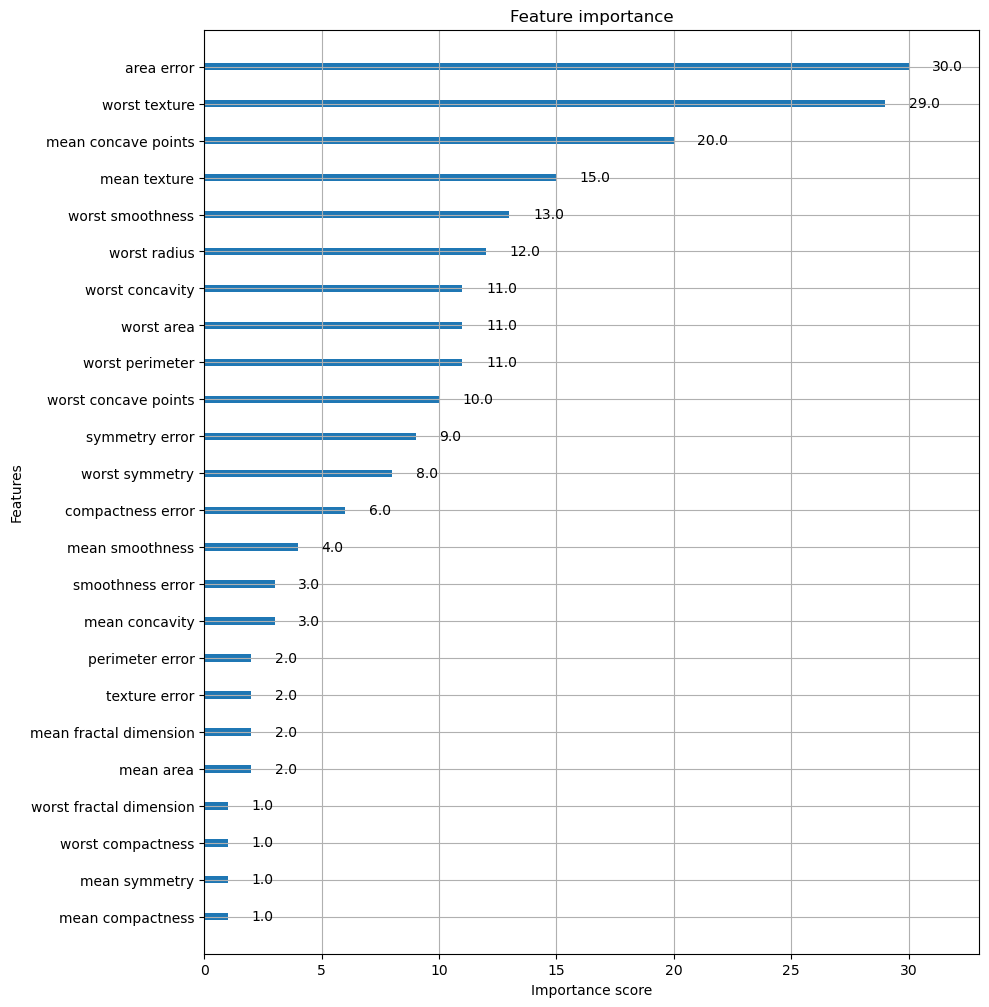

In [40]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots(figsize =(10, 12))
plot_importance(model, ax = ax)
plt.show()